# Predicting Diabetes Progression: Model Comparison and Regularization

Using scikit-learn's diabetes dataset (442 patients, 10 baseline measurements),
I compare four regression approaches and examine what the results can and cannot
tell us.

**Models compared:** single-feature linear regression, multiple linear regression,
k-nearest neighbours, and LASSO.

**Key findings**

- Using all 10 features nearly doubles the R2 over the strongest single predictor (0.233 to 0.453)
- KNN underperforms despite tuning: the data is close to linear and 10 dimensions is sparse for 353 training samples
- LASSO with a cross-validated alpha gives the best result (R2 = 0.471) using only 7 of the 10 features
- Even the best model has RMSE 53.9 against a test-set target standard deviation of 73.2, so it is useful but far from clinically usable

**Note on methodology:** every hyperparameter (k for KNN, alpha for LASSO) is
selected by cross-validation on the training set only. The test set is used once,
at the end, for final evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42

## The data

Ten baseline variables (age, sex, BMI, average blood pressure and six blood serum
measurements) were collected for 442 diabetes patients. The target is a
quantitative measure of how much their disease progressed over the following year.

All features are already mean-centred and scaled, so no further standardization is
needed before fitting penalized models.

In [2]:
diabetes = load_diabetes()

df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print(f'{df.shape[0]} patients, {df.shape[1] - 1} features')
df.head()

442 patients, 10 features


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f'train: {len(X_train)} patients   test: {len(X_test)} patients')
print(f'target range     : {y.min():.0f} to {y.max():.0f}')
print(f'test target std  : {y_test.std():.1f}')

train: 353 patients   test: 89 patients
target range     : 25 to 346
test target std  : 73.2


That last number is the one to keep in mind. If I built no model at all and simply
predicted the average for every patient, my typical error would be the standard
deviation of the target. That is the bar any model has to clear.

## Which features relate to disease progression?

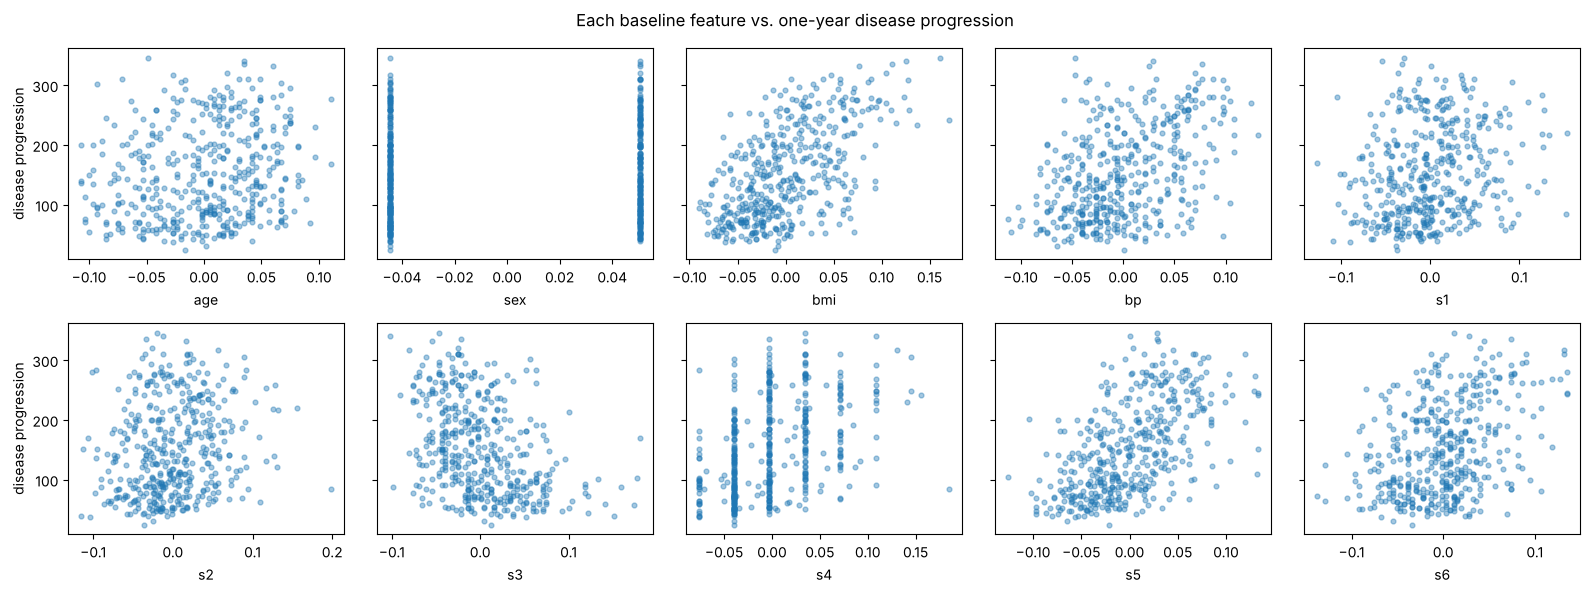

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharey=True)

for ax, col in zip(axes.ravel(), X.columns):
    ax.scatter(df[col], df['target'], alpha=0.4, s=12)
    ax.set_xlabel(col)

axes[0, 0].set_ylabel('disease progression')
axes[1, 0].set_ylabel('disease progression')
fig.suptitle('Each baseline feature vs. one-year disease progression')
fig.tight_layout()
plt.show()

In [5]:
correlations = df.corr()['target'].drop('target').sort_values(ascending=False)
print(correlations.round(3))

bmi    0.586
s5     0.566
bp     0.441
s4     0.430
s6     0.382
s1     0.212
age    0.188
s2     0.174
sex    0.043
s3    -0.395
Name: target, dtype: float64


BMI is the strongest single predictor (r = 0.586), followed closely by `s5`
(log serum triglycerides, r = 0.566).

This is plausible. Every subject here is already diabetic, so the target measures
deterioration rather than onset. Higher BMI is associated with greater insulin
resistance, which makes blood glucose harder to control, so those patients would
be expected to worsen faster. Weight management is also a standard first-line
recommendation in diabetes care.

The scatter plots are worth a second look: the relationships all appear roughly
linear and additive, with no obvious curvature or clustering. That becomes
relevant when KNN underperforms later.

## Evaluation helper

Every model is scored the same way so the numbers stay comparable. Reporting RMSE
alongside MSE matters because RMSE is in the same units as the target, which makes
it directly comparable to the standard deviation above.

In [6]:
results = {}

def report(name, y_pred, n_features, train_r2=None):
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'Test MSE': round(mse, 1),
        'Test RMSE': round(np.sqrt(mse), 1),
        'Test R2': round(r2, 3),
        'Train R2': round(train_r2, 3) if train_r2 is not None else np.nan,
        'Features': n_features,
    }

    print(f'--- {name} ---')
    print(f'MSE      : {mse:.1f}')
    print(f'RMSE     : {np.sqrt(mse):.1f}   (test target std = {y_test.std():.1f})')
    print(f'Test  R2 : {r2:.3f}')
    if train_r2 is not None:
        print(f'Train R2 : {train_r2:.3f}')
    print()

## Baseline: how far does the strongest single feature get us?

In [7]:
bmi_train = X_train[['bmi']]
bmi_test = X_test[['bmi']]

m_bmi = LinearRegression().fit(bmi_train, y_train)

print(f'intercept = {m_bmi.intercept_:.1f}')
print(f'slope     = {m_bmi.coef_[0]:.1f}')
print()

report('Linear (bmi only)', m_bmi.predict(bmi_test), 1,
       r2_score(y_train, m_bmi.predict(bmi_train)))

intercept = 152.0
slope     = 998.6

--- Linear (bmi only) ---
MSE      : 4061.8
RMSE     : 63.7   (test target std = 73.2)
Test  R2 : 0.233
Train R2 : 0.366



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


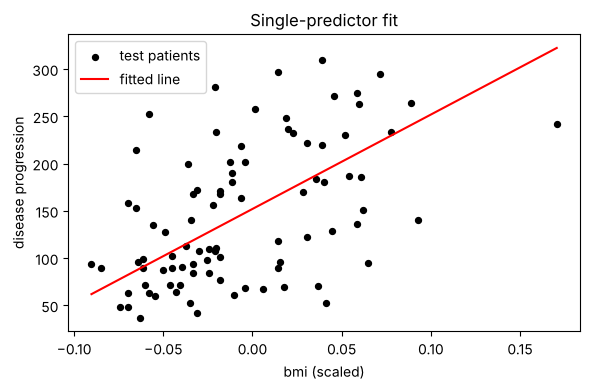

In [8]:
plt.figure(figsize=(6, 4))
plt.scatter(bmi_test['bmi'], y_test, color='black', s=18, label='test patients')

grid = np.linspace(X['bmi'].min(), X['bmi'].max(), 100).reshape(-1, 1)
plt.plot(grid, m_bmi.predict(grid), color='red', label='fitted line')

plt.xlabel('bmi (scaled)')
plt.ylabel('disease progression')
plt.title('Single-predictor fit')
plt.legend()
plt.tight_layout()
plt.show()

An R2 of 0.233 means BMI alone explains under a quarter of the variation in how
patients deteriorate. The strongest single feature is a long way from a sufficient
model.

## Does adding the other nine features help?

In [9]:
m_all = LinearRegression().fit(X_train, y_train)

report('Linear (all 10)', m_all.predict(X_test), 10,
       r2_score(y_train, m_all.predict(X_train)))

pd.Series(m_all.coef_, index=X.columns).round(1).sort_values(ascending=False)

--- Linear (all 10) ---
MSE      : 2900.2
RMSE     : 53.9   (test target std = 73.2)
Test  R2 : 0.453
Train R2 : 0.528



s5     736.2
bmi    542.4
s2     518.1
bp     347.7
s4     275.3
s3     163.4
s6      48.7
age     37.9
sex   -242.0
s1    -931.5
dtype: float64

R2 nearly doubles, from 0.233 to 0.453. Disease progression is clearly
multifactorial: `s5`, `bp` and `s3` each carry information that BMI does not.

Note also that train R2 (0.528) exceeds test R2 (0.453). That gap is the signature
of mild overfitting, which is expected when fitting 10 coefficients on 353 samples
and sets up the case for regularization later.

## Would a non-linear model do better?

Linear regression assumes a straight-line relationship. KNN makes no such
assumption, so if the data has local structure it should win. The number of
neighbours k is chosen by 5-fold cross-validation on the training set.

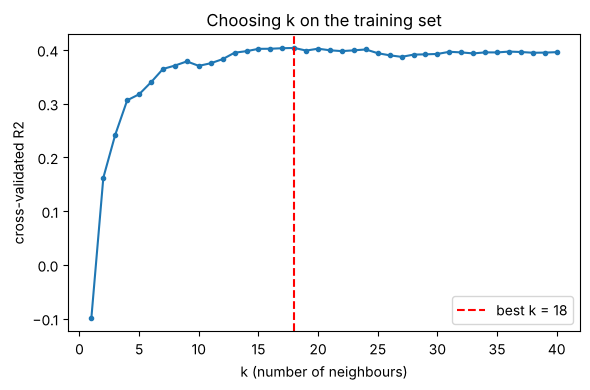

In [10]:
k_range = range(1, 41)

cv_scores = [
    cross_val_score(KNeighborsRegressor(n_neighbors=k),
                    X_train, y_train, cv=5, scoring='r2').mean()
    for k in k_range
]

best_k = k_range[int(np.argmax(cv_scores))]

plt.figure(figsize=(6, 4))
plt.plot(k_range, cv_scores, marker='o', ms=3)
plt.axvline(best_k, color='red', ls='--', label=f'best k = {best_k}')
plt.xlabel('k (number of neighbours)')
plt.ylabel('cross-validated R2')
plt.title('Choosing k on the training set')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
m_knn = KNeighborsRegressor(n_neighbors=best_k).fit(X_train, y_train)

report(f'KNN (k={best_k})', m_knn.predict(X_test), 10,
       r2_score(y_train, m_knn.predict(X_train)))

--- KNN (k=18) ---
MSE      : 3083.9
RMSE     : 55.5   (test target std = 73.2)
Test  R2 : 0.418
Train R2 : 0.501



KNN loses to the linear model. Two likely reasons:

1. **Sparsity in 10 dimensions.** With only 353 training samples spread over 10
   features, a point's nearest neighbours are not actually very close, so averaging
   them produces a noisy prediction.
2. **The data is close to linear.** The scatter plots showed no curvature, so KNN's
   extra flexibility buys nothing while adding variance.

The chosen k is itself informative. Cross-validation settled on a large value,
which amounts to heavy smoothing: the model is telling us the local signal is weak
and it would rather average it away. The limit of that behaviour is k = 353, where
every prediction becomes the training mean and R2 falls to zero.

I extended the search to `range(1, 41)` to confirm the CV curve has a genuine
interior maximum rather than being truncated by too narrow a search range.

## Can regularization improve on OLS?

LASSO adds a penalty on the size of the coefficients:

$$\min_\beta \ \sum (y_i - \hat{y}_i)^2 + \alpha \sum_j |\beta_j|$$

Because the penalty uses absolute values, coefficients can be driven to exactly
zero rather than merely shrunk, so LASSO performs feature selection as a side
effect. Larger alpha means a heavier penalty and fewer surviving features.

In [12]:
for a in [0.01, 0.1, 0.5, 1, 5]:
    las = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    coef = pd.Series(las.coef_, index=X_train.columns)
    print(f'alpha = {a}')
    print(f'  kept   : {list(coef[coef != 0].index)}')
    print(f'  zeroed : {list(coef[coef == 0].index)}')
    print()

alpha = 0.01
  kept   : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
  zeroed : []

alpha = 0.1
  kept   : ['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']
  zeroed : ['age', 's2', 's4']

alpha = 0.5
  kept   : ['bmi', 'bp', 's3', 's5']
  zeroed : ['age', 'sex', 's1', 's2', 's4', 's6']

alpha = 1
  kept   : ['bmi', 'bp', 's5']
  zeroed : ['age', 'sex', 's1', 's2', 's3', 's4', 's6']

alpha = 5
  kept   : []
  zeroed : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']



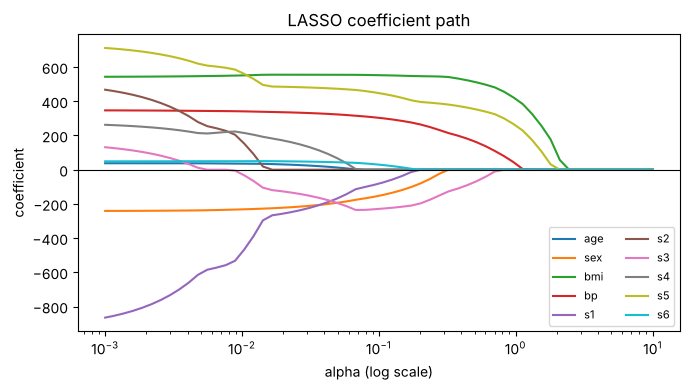

In [13]:
alpha_grid = np.logspace(-3, 1, 60)
paths = np.array([
    Lasso(alpha=a, max_iter=10000).fit(X_train, y_train).coef_
    for a in alpha_grid
])

plt.figure(figsize=(7, 4))
for i, name in enumerate(X_train.columns):
    plt.plot(alpha_grid, paths[:, i], label=name)

plt.xscale('log')
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('alpha (log scale)')
plt.ylabel('coefficient')
plt.title('LASSO coefficient path')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

The order in which features disappear is the interesting part. The last survivors
are `bmi`, `bp` and `s5`, matching the correlation analysis from earlier. Two
independent methods agreeing on the same shortlist is reassuring.

The earliest casualties are `age`, `s2` and `s4`, and this needs care to interpret.
**Being zeroed does not mean a feature is medically irrelevant.** It means the
feature adds no information *given the others*. Features `s1` through `s4` are all
cholesterol measurements: `s1` is total cholesterol, `s2` is LDL, `s3` is HDL, and
`s4` is the total-cholesterol-to-HDL ratio. Since `s4` is computed from `s1` and
`s3`, it is redundant by construction. When features overlap like this, LASSO keeps
one and drops the rest, because paying the penalty twice buys almost nothing new.
Dropping `s2` therefore does not imply LDL is unrelated to diabetes, only that the
other serum measurements already capture it.

`age` is easier to justify directly: every subject here is already diabetic, so
once BMI and the serum measurements are known, age may genuinely add little
marginal predictive power.

### How does the penalty affect performance?

In [14]:
ols_r2 = r2_score(y_test, m_all.predict(X_test))

print('   alpha    Test R2   features')
print(f'     OLS   {ols_r2:8.4f}   {10:8d}')

for a in [0.01, 0.05, 0.1, 0.3, 0.5, 1, 5]:
    las = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    n_kept = int((las.coef_ != 0).sum())
    print(f'{a:8}   {r2_score(y_test, las.predict(X_test)):8.4f}   {n_kept:8d}')

   alpha    Test R2   features
     OLS     0.4526         10
    0.01     0.4567         10
    0.05     0.4675          9
     0.1     0.4719          7
     0.3     0.4580          5
     0.5     0.4441          4
       1     0.3576          3
       5    -0.0120          0


The curve rises, peaks, then falls. With a small penalty, shrinking the
coefficients counteracts the overfitting seen earlier (train 0.528 vs. test 0.453)
and test performance improves. Past a certain point the penalty is heavy enough to
suppress genuinely useful features too, and performance collapses.

The right-hand end of that curve has a definite destination, worth checking
explicitly.

In [15]:
las5 = Lasso(alpha=5, max_iter=10000).fit(X_train, y_train)
pred5 = las5.predict(X_test)

print('unique predictions :', np.unique(pred5))
print('training mean      :', round(y_train.mean(), 2))
print('RMSE               :', round(np.sqrt(mean_squared_error(y_test, pred5)), 2))
print('test target std    :', round(y_test.std(), 2))
print('R2                 :', round(r2_score(y_test, pred5), 4))

unique predictions : [153.73654391]
training mean      : 153.74
RMSE               : 73.22
test target std    : 73.2
R2                 : -0.012


With every coefficient at zero the model has only an intercept left, so it predicts
a single value for every patient. Its RMSE is essentially the standard deviation of
the test target, confirming that a large enough alpha reduces the model to the
no-model baseline.

The R2 lands just below zero rather than exactly at zero because the model predicts
the *training* mean, not the test mean. Being slightly off makes it marginally
worse than a perfect mean-guess.

### Choosing alpha honestly

The sweep above suggests a value near 0.1, but selecting alpha by looking at the
test set would leak information and produce an optimistic score. `LassoCV` instead
picks alpha by 5-fold cross-validation on the training set, leaving the test set
untouched until the final evaluation. This is the same procedure used to choose k
for KNN.

In [16]:
lcv = LassoCV(alphas=np.logspace(-3, 1, 200), cv=5, max_iter=10000).fit(X_train, y_train)

coef = pd.Series(lcv.coef_, index=X_train.columns)
n_kept = int((lcv.coef_ != 0).sum())

print(f'alpha chosen by CV : {lcv.alpha_:.4f}')
print(f'features kept      : {n_kept}')
print(f'zeroed out         : {list(coef[coef == 0].index)}')
print()

report('LASSO (CV alpha)', lcv.predict(X_test), n_kept,
       r2_score(y_train, lcv.predict(X_train)))

alpha chosen by CV : 0.0775
features kept      : 7
zeroed out         : ['age', 's2', 's4']

--- LASSO (CV alpha) ---
MSE      : 2800.4
RMSE     : 52.9   (test target std = 73.2)
Test  R2 : 0.471
Train R2 : 0.519



The cross-validated alpha lands close to the value the manual sweep identified, and
zeroes out the same three features. Reaching essentially the same answer without
touching the test set means the score can be reported without a leakage caveat.

## Results

In [17]:
pd.DataFrame(results).T

,Test MSE,Test RMSE,Test R2,Train R2,Features
Linear (bmi only),4061.8,63.7,0.233,0.366,1.0
Linear (all 10),2900.2,53.9,0.453,0.528,10.0
KNN (k=18),3083.9,55.5,0.418,0.501,10.0
LASSO (CV alpha),2800.4,52.9,0.471,0.519,7.0


## Discussion

**One feature is not enough.** BMI has the highest correlation with the target, but
alone it explains only about 23% of the variance. Using all ten features nearly
doubles R2, confirming that disease progression is driven by several factors
rather than one.

**Flexibility is not automatically an advantage.** KNN, properly tuned, still loses
to ordinary least squares here. With 353 samples spread over 10 dimensions the
nearest neighbours are not meaningfully near, and the underlying relationship
appears linear anyway, so the extra flexibility only adds variance.

**Regularization helps, and simplifies.** LASSO with a cross-validated alpha beats
OLS on the test set while using only 7 of the 10 features. Shrinking the
coefficients counteracts the mild overfitting visible in the OLS train/test gap.
The model gets both better and simpler.

**But how good is the best model, really?** Predicting the mean for every patient
would give a typical error equal to the test-set standard deviation of 73.2. The
best model reduces this to RMSE 53.9, about 74% of the no-model error. It learns
real signal. But the target ranges from roughly 25 to 346, so an error of plus or
minus 54 is far too coarse to inform an actual clinical decision. Saying a patient
will reach 180 when the truth could be 126 or 234 is not useful.

**A caveat on the feature selection.** Which of the collinear cholesterol features
survives can change with a different train/test split, since LASSO's choice among
near-duplicate features is unstable. These results should not be read as evidence
that these specific variables are the medically important ones.